In [41]:
# SIT215 Assignment 1: Truck Delivery Navigation System
# Student ID: s224529554
# Date: 17 April 2026

import heapq
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List, Tuple, Optional, Set
from collections import deque

## TASK 1: Environment Modelling and Problem Formulation 
    The guide with around 20 lanmarks and 35 path segments in your graph is a reasonable configuration for you to implement

In [42]:
class TruckDeliveryEnvironment:
    """
    Real-World environment modelled on Deakin Burwood Campus. 
    Models a truck delivery system with 22 landmarks and 31 path segments.
    """

    def __init__(self):
        #Define landmarks and paths (node) -22 locations and 31 paths
        self.landmarks = {
            'Gate2': (0, 0),           # Entry point
            'BCC': (2, 4),             # Burwood Corporate Centre
            'BuildingP': (4, 1),       # Building P
            'BuildingLB': (6, 3),      # Building LB
            'BuildingEF': (8, 2),      # Building EF
            'BuildingEB': (10, 4),     # Building EB
            'BuildingMB': (7, 6),      # Building MB
            'Library': (5, 5),         # Deakin Library Burwood
            'ArtGallery': (3, 7),      # Deakin University Art Gallery
            'BuildingJ': (1, 6),       # Building J
            'BuildingBC': (9, 1),      # Building BC
            'DeliveryHub': (11, 3),    # ALL DELIVERIES point
            'Parking': (8, 8),         # Deakin Parking
            'BuildingLA': (4, 9),      # Building LA
            'BuildingIC': (6, 10),     # Building IC
            'CHL': (2, 8),             # Centre for Humanitarian Leadership
            'Bridge': (7, 4),          # Deakin University Bridge
            'FitnessCentre': (9, 6),   # Deakin Active
            'BuildingHD': (5, 11),     # Building HD
            'BuildingKW': (3, 10),     # Building KW
            'BuildingLC': (1, 9),      # Building LC
            'Gate1': (12, 5)           # Exit point
        }

        #Define paths (edges) with costs (distance in arbitrary units)
        #Each edge: (from, to, cost)

        self.paths = [
            ('Gate2', 'BCC', 4), ('BCC', 'BuildingP', 3), ('BuildingP', 'BuildingLB', 3),
            ('BuildingLB', 'BuildingEF', 2), ('BuildingEF', 'BuildingEB', 3), 
            ('BuildingEB', 'DeliveryHub', 2), ('DeliveryHub', 'Gate1', 3),
            ('BuildingLB', 'BuildingMB', 3), ('BuildingMB', 'Library', 2), ('Library', 'ArtGallery', 2),
            ('ArtGallery', 'BuildingJ', 2), ('BuildingJ', 'Gate2', 3),
            ('BuildingEF', 'BuildingBC', 3), ('BuildingBC', 'DeliveryHub', 2),
            ('BuildingEB', 'Bridge', 2), ('Bridge', 'FitnessCentre', 3),
            ('FitnessCentre', 'Parking', 3), ('Parking', 'BuildingLA', 2),
            ('BuildingLA', 'BuildingIC', 2), ('BuildingIC', 'BuildingHD', 2),
            ('BCC', 'BuildingJ', 3), ('BuildingP', 'BuildingBC', 4),
            ('BuildingMB', 'BuildingIC', 2), ('BuildingKW', 'ArtGallery', 3)
        ]
        
        #Building graph representation
        self.graph = self.build_graph()

        self.static_constraints = {
            'narrow_roads': ['BuildingP_to_BuildingLB', 'BuildingEF_to_BuildingEB',
                           'CHL_to_BuildingKW', 'BuildingKW_to_BuildingLC'],
            'truck_height_restrictions': ['Library_to_Parking', 'ArtGallery_to_Parking']
        }

        self.dynamic_constraints = {
            'delivery_hours': (9, 17),
            'peak_hours': [8, 10, 16, 18]
        }

    def build_graph(self) -> Dict[str, List[Tuple[str, int]]]:
        """Builds a graph representation of the environment."""
        graph = {node: {} for node in self.landmarks}
        for a, b, cost in self.paths:
            graph[a][b] = cost
            graph[b][a] = cost
        return graph
    
    def is_path_feasible(self, from_node: str, to_node: str, current_time: int) -> bool:
        """Checks if a path is feasible given constraints.
        
        Args:
            from_node: Starting Landmark
            to_node: Destination Landmark
            current_time: Hour of the day (0-23)

        Returns:
            True if path is feasible, False otherwise.
        """
        edge_key = f"{from_node}_to_{to_node}"

        if edge_key in self.static_constraints['narrow_roads']:
            return False
        
        if edge_key in self.static_constraints['truck_height_restrictions']:
            if not (self.dynamic_constraints['delivery_hours'][0] <= 
                    current_time <= 
                    self.dynamic_constraints['delivery_hours'][1]):
                return False
        return True
    
    def get_percepts(self, location: str, current_time: int = 12) -> Dict:
        """Return percepts from the environment."""
        return {
            'location': location,
            'time': current_time,
            'is_delivery_point': location == 'DeliveryHub',
            'feasible_moves': self.get_feasible_moves(location, current_time)
        }
    
    def get_feasible_moves(self, location: str, current_time: int = 12) -> List[str]:
        """Return list of feasible next locations from current position."""
        feasible = []
        for neighbor in self.graph.get(location, {}):
            if self.is_path_feasible(location, neighbor, current_time):
                feasible.append(neighbor)
        return feasible

## TASK 2: Search Algorithm Implementation
This section defines the uninformed comparison algorithm (`UCS`) and the informed benchmark (`A*`).
The new landmark heuristic is already included in the environment model above.


In [43]:
def manhattan_distance(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

class DeliveryPlanningProblem:
    """
    State space formulation for the truck delivery problem.
    State = (Location, time, delivered_status)
    """

    def __init__(self, env: TruckDeliveryEnvironment, start: str, goal: str):
        self.env = env
        self.start = start
        self.goal = goal
        self.initial_state = (start, 8, False)

    def goal_test(self, state: Tuple) -> bool:
        """Check if the state is a goal state."""
        location, time, delivered = state
        return location == self.goal and delivered
    
    def successors(self, state: Tuple) -> List[Tuple[str, Tuple]]:
        """
        Generate all valid successor states.
        Returns lists of (action, next_state) pairs.
        """

        location, time, delivered = state
        successors_list = []

        for neighbor in self.env.get_feasible_moves(location, time):
            new_time = (time + 1) % 24
            new_delivered = delivered
            action = f"move_to_{neighbor}"
            successors_list.append((action, (neighbor, new_time, new_delivered)))

        #Delivery action (only at delivery hub and if not yet delivered)
        if location == self.goal and not delivered:
            action = "deliver"
            successors_list.append((action, (location, time, True)))

        return successors_list
    
    def step_cost(self, from_state: Tuple, action: str, to_state: Tuple) -> int:
        """Calculate the cost of taking an action from one state to another."""
        from_location, _, _ = from_state
        to_location, _, _ = to_state

        if action == "deliver":
            return 0
        
        return self.env.graph[from_location].get(to_location, float('inf'))

#HEURISTIC FUNCTIONS

def baseline_heuristic(state: Tuple, env: TruckDeliveryEnvironment, goal: str) -> int:
    location, time, delivered = state
    if delivered:
        return 0

    goal_pos = env.landmarks[goal]
    current_pos = env.landmarks[location]

    return manhattan_distance(current_pos, goal_pos)

def enhanced_heuristic(state: Tuple, env: TruckDeliveryEnvironment, goal: str) -> int:
    location, time, delivered = state
    if delivered:
        return 0
    
    goal_pos = env.landmarks[goal]
    current_pos = env.landmarks[location]

    distance = manhattan_distance(current_pos, goal_pos)

    constraint_penalty = 0
    if location in ['BuildingP', 'BuildingEF', 'CHL', 'BuildingKW']:
        constraint_penalty = 2

    time_penalty = 0
    if not delivered and location == 'DeliveryHub':
        if time < 9 or time > 17:
            time_penalty = 1

    return distance + constraint_penalty + time_penalty

#SEARCH ALGORITHMS

def astar_search(problem: DeliveryPlanningProblem, heuristic_func, 
                 env: TruckDeliveryEnvironment, goal: str) -> Dict:
    
    """
     A* search algorithm implementation.
    
    Returns dictionary with:
    - path: list of actions
    - cost: total path cost
    - nodes_expanded: number of nodes expanded
    - expanded_nodes: list of expanded states
    - time_taken: execution time
    """

    start_time = time.time()

    #Priority queue: (f_score, g_score, state, path)
    frontier = []
    start_state = problem.initial_state
    initial_h = heuristic_func(start_state, env, goal)
    heapq.heappush(frontier, (initial_h, 0, start_state, []))

    #Track best g scores
    best_g = {start_state: 0}
    explored = set()
    nodes_expanded = 0
    expanded_nodes = []

    while frontier:
        f_score, g_score, current_state, path = heapq.heappop(frontier)

        if current_state in explored:
            continue

        explored.add(current_state)
        expanded_nodes.append(current_state)
        nodes_expanded += 1

        if problem.goal_test(current_state):
            result = {
                'path': path,
                'cost': g_score,
                'nodes_expanded': nodes_expanded,
                'expanded_nodes': expanded_nodes,
                'time_taken': time.time() - start_time,
                'found': True
            }
            return result

        for action, next_state in problem.successors(current_state):
            new_g = g_score + problem.step_cost(current_state, action, next_state)
            new_h = heuristic_func(next_state, env, goal)
            new_f = new_g + new_h
            
            if next_state not in best_g or new_g < best_g[next_state]:
                best_g[next_state] = new_g
                heapq.heappush(frontier, (new_f, new_g, next_state, path + [action]))
    
    return {
        'path': None,
        'cost': None,
        'nodes_expanded': nodes_expanded,
        'expanded_nodes': expanded_nodes,
        'time_taken': time.time() - start_time,
        'found': False
    }


def uniform_cost_search(problem: DeliveryPlanningProblem) -> Dict:
    """
    Uniform Cost Search (informed by path cost only).
    Used as comparison algorithm for Task 2.
    """
    start_time = time.time()
    
    # Priority queue: (g_score, state, path)
    frontier = []
    start_state = problem.initial_state
    heapq.heappush(frontier, (0, start_state, []))
    
    best_g = {start_state: 0}
    explored = set()
    nodes_expanded = 0
    expanded_nodes = []
    
    while frontier:
        g_score, state, path = heapq.heappop(frontier)
        
        if state in explored:
            continue
        
        explored.add(state)
        nodes_expanded += 1
        expanded_nodes.append(state)
        
        if problem.goal_test(state):
            return {
                'path': path,
                'cost': g_score,
                'nodes_expanded': nodes_expanded,
                'expanded_nodes': expanded_nodes,
                'time_taken': time.time() - start_time,
                'found': True
            }
        
        for action, next_state in problem.successors(state):
            new_g = g_score + problem.step_cost(state, action, next_state)
            
            if next_state not in best_g or new_g < best_g[next_state]:
                best_g[next_state] = new_g
                heapq.heappush(frontier, (new_g, next_state, path + [action]))
    
    return {
        'path': None,
        'cost': None,
        'nodes_expanded': nodes_expanded,
        'expanded_nodes': expanded_nodes,
        'time_taken': time.time() - start_time,
        'found': False
    }

## Task 3 and Task 4: Evaluation, Logical Validation, And Output Generation

This section adds forward chaining for route feasibility, exports tables and SVG visuals, and runs the evaluation cases.


In [44]:
def evaluate_algorithms(env: TruckDeliveryEnvironment, test_cases: List[Tuple[str, str]]):
    """ 
    Evaluate A* and UCS on multiple test cases.
    """
    results = []
    
    for i, (start, goal) in enumerate(test_cases):
        print(f"\n{'='*60}")
        print(f"Test Case {i+1}: {start} -> {goal}")
        print(f"{'='*60}")

        problem = DeliveryPlanningProblem(env, start, goal)
        print("\nRunning A* Search with Baseline Heuristic...")
        astar_baseline_result = astar_search(problem, baseline_heuristic, env, goal)

        print("\nRunning Uniform Cost Search...")
        ucs_result = uniform_cost_search(problem)

        results.append({
            'test_case': f"{start}→{goal}",
            'astar_cost': astar_baseline_result['cost'],
            'ucs_cost': ucs_result['cost'],
            'astar_nodes': astar_baseline_result['nodes_expanded'],
            'ucs_nodes': ucs_result['nodes_expanded'],
            'astar_time': astar_baseline_result['time_taken'],
            'ucs_time': ucs_result['time_taken'],
            'astar_found': astar_baseline_result['found'],
            'ucs_found': ucs_result['found'],
            'astar_path': astar_baseline_result['path'],
            'ucs_path': ucs_result['path'] 
        })

        print(f"\n--- A* Results ---")
        print(f"Solution found: {astar_baseline_result['found']}")
        if astar_baseline_result['found']:
            print(f"Path cost: {astar_baseline_result['cost']}")
            print(f"Nodes expanded: {astar_baseline_result['nodes_expanded']}")
            print(f"Time: {astar_baseline_result['time_taken']:.6f} seconds")
            print(f"Path: {' → '.join(astar_baseline_result['path'])}")
        
        print(f"\n--- UCS Results ---")
        print(f"Solution found: {ucs_result['found']}")
        if ucs_result['found']:
            print(f"Path cost: {ucs_result['cost']}")
            print(f"Nodes expanded: {ucs_result['nodes_expanded']}")
            print(f"Time: {ucs_result['time_taken']:.6f} seconds")
            print(f"Path: {' → '.join(ucs_result['path'])}")
    
    return results

In [45]:
def evaluate_heuristics(env: TruckDeliveryEnvironment, test_cases: List[Tuple[str, str]]):
    """
    Compare baseline vs enhanced heuristic for Task 4.
    """
    heuristic_results = []
    
    for start, goal in test_cases:
        print(f"\n{'='*60}")
        print(f"Comparing Heuristics: {start} -> {goal}")
        print(f"{'='*60}")
        
        problem = DeliveryPlanningProblem(env, start, goal)
        
        # Baseline heuristic
        print("\n--- Baseline Heuristic (Manhattan Distance) ---")
        baseline_result = astar_search(problem, baseline_heuristic, env, goal)
        
        # Enhanced heuristic
        print("\n--- Enhanced Heuristic ---")
        enhanced_result = astar_search(problem, enhanced_heuristic, env, goal)
        
        heuristic_results.append({
            'test_case': f"{start}→{goal}",
            'baseline_cost': baseline_result['cost'],
            'enhanced_cost': enhanced_result['cost'],
            'baseline_nodes': baseline_result['nodes_expanded'],
            'enhanced_nodes': enhanced_result['nodes_expanded'],
            'baseline_time': baseline_result['time_taken'],
            'enhanced_time': enhanced_result['time_taken'],
            'improvement_pct': ((baseline_result['nodes_expanded'] - enhanced_result['nodes_expanded']) 
                               / baseline_result['nodes_expanded'] * 100) if baseline_result['nodes_expanded'] > 0 else 0
        })
        
        if baseline_result['found'] and enhanced_result['found']:
            print(f"\nImprovement: {heuristic_results[-1]['improvement_pct']:.1f}% fewer nodes expanded")
    
    return heuristic_results

#VISUALIZATION FUNCTIONS

def plot_comparison_results(results: List[Dict]):
    """Plot comparison of heuristics and algorithms."""
    test_cases = [r['test_case'] for r in results]
    astar_nodes = [r['astar_nodes'] for r in results]
    ucs_nodes = [r['ucs_nodes'] for r in results]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    x = np.arange(len(test_cases))
    width = 0.35
    axes[0].bar(x - width/2, astar_nodes, width, label='A*', color='skyblue')
    axes[0].bar(x + width/2, ucs_nodes, width, label='UCS', color='lightcoral')
    axes[0].set_xlabel('Test Case')
    axes[0].set_ylabel('Nodes Expanded')
    axes[0].set_title('Nodes Expanded: A* vs UCS')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(test_cases, rotation=45, ha='right')
    axes[0].legend()

    astar_time = [r['astar_time'] for r in results]
    ucs_time = [r['ucs_time'] for r in results]
    axes[1].bar(x - width/2, astar_time, width, label='A*', color='skyblue')
    axes[1].bar(x + width/2, ucs_time, width, label='UCS', color='lightcoral')
    axes[1].set_xlabel('Test Case')
    axes[1].set_ylabel('Time (seconds)')
    axes[1].set_title('Execution Time: A* vs UCS')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(test_cases, rotation=45, ha='right')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('algorithm_comparison.png')
    plt.show()

In [46]:
def plot_heuristic_comparison(heuristic_results: List[Dict]):
    """Create visualization comparing heuristic performance."""
    test_cases = [r['test_case'] for r in heuristic_results]
    baseline_nodes = [r['baseline_nodes'] for r in heuristic_results]
    enhanced_nodes = [r['enhanced_nodes'] for r in heuristic_results]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(test_cases))
    width = 0.35
    
    ax.bar(x - width/2, baseline_nodes, width, label='Baseline Heuristic', color='lightgreen')
    ax.bar(x + width/2, enhanced_nodes, width, label='Enhanced Heuristic', color='orange')
    
    ax.set_xlabel('Test Case')
    ax.set_ylabel('Nodes Expanded')
    ax.set_title('Nodes Expanded: Baseline vs Enhanced Heuristic')
    ax.set_xticks(x)
    ax.set_xticklabels(test_cases, rotation=45, ha='right')
    ax.legend()
    
    # Add improvement annotations
    for i, r in enumerate(heuristic_results):
        improvement = r['improvement_pct']
        ax.annotate(f'-{improvement:.0f}%', 
                   xy=(i, (baseline_nodes[i] + enhanced_nodes[i])/2),
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('heuristic_comparison.png', dpi=150)
    plt.show()

In [47]:
def visualize_graph(env: TruckDeliveryEnvironment):
    """Visualize the campus map with landmarks and paths."""
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Plot nodes
    for node, (x, y) in env.landmarks.items():
        ax.plot(x, y, 'o', markersize=10, color='blue')
        ax.annotate(node, (x, y), xytext=(5, 5), textcoords='offset points', 
                   fontsize=8, fontweight='bold')
    
    # Plot edges
    for a, b, cost in env.paths:
        x1, y1 = env.landmarks[a]
        x2, y2 = env.landmarks[b]
        ax.plot([x1, x2], [y1, y2], 'gray', linewidth=1, alpha=0.7)
        
        # Annotate costs at midpoints
        mx, my = (x1 + x2)/2, (y1 + y2)/2
        ax.annotate(str(cost), (mx, my), fontsize=7, color='red', ha='center')
    
    # Highlight constraints
    for edge in env.static_constraints['narrow_roads']:
        parts = edge.split('_to_')
        if len(parts) == 2:
            x1, y1 = env.landmarks.get(parts[0], (None, None))
            x2, y2 = env.landmarks.get(parts[1], (None, None))
            if x1 and x2:
                ax.plot([x1, x2], [y1, y2], 'orange', linewidth=3, alpha=0.5)
    
    ax.set_title('Deakin Burwood Campus - Truck Delivery Map', fontsize=14, fontweight='bold')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.savefig('campus_map.png', dpi=150)
    plt.show()

SIT215 Assignment 1: Truck Delivery Navigation System

[1] Initializing Truck Delivery Environment...
   - 22 landmarks
   - 24 path segments
   - Static constraints: narrow roads, height restrictions
   - Dynamic constraints: delivery hours, peak hours

[2] Visualizing campus map...


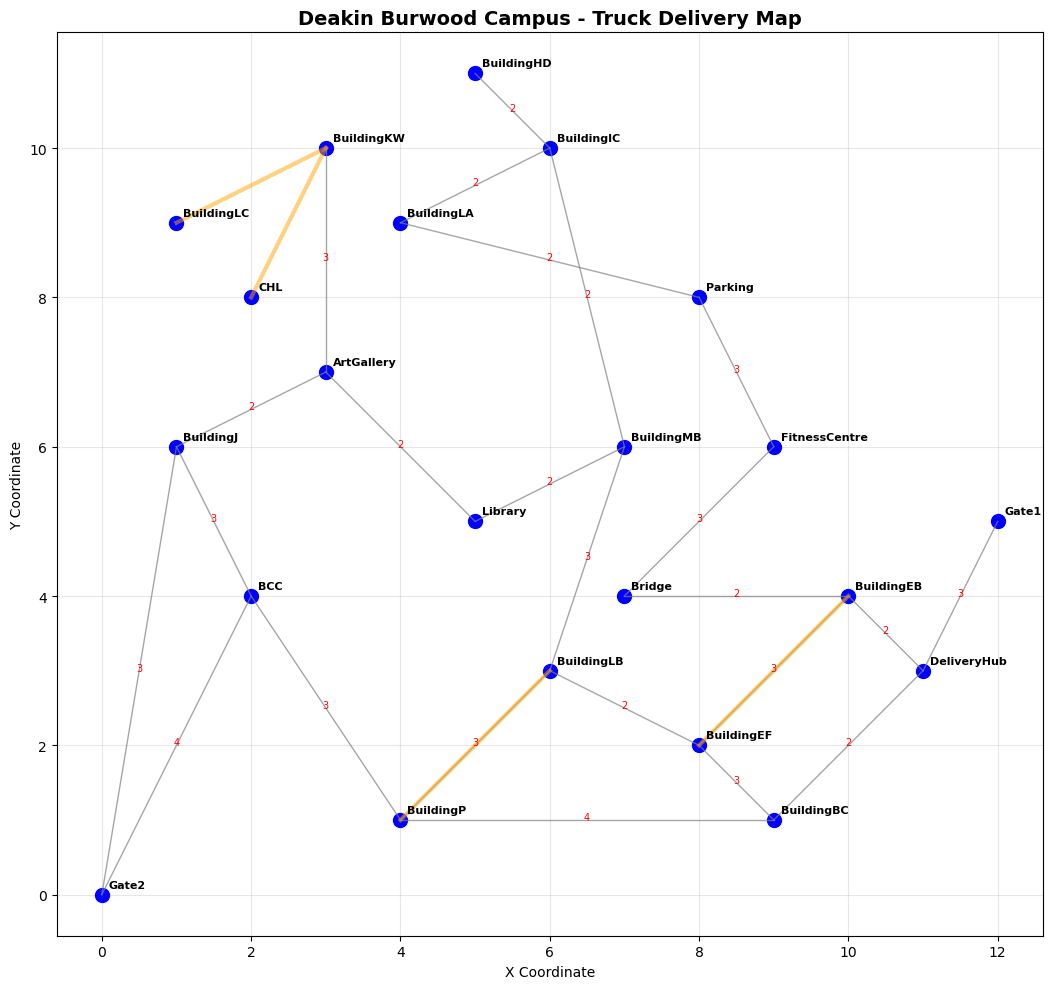


[3] Evaluating Search Algorithms (Task 3)...

Test Case 1: Gate2 -> DeliveryHub

Running A* Search with Baseline Heuristic...

Running Uniform Cost Search...

--- A* Results ---
Solution found: True
Path cost: 13
Nodes expanded: 8
Time: 0.000000 seconds
Path: move_to_BCC → move_to_BuildingP → move_to_BuildingBC → move_to_DeliveryHub → deliver

--- UCS Results ---
Solution found: True
Path cost: 13
Nodes expanded: 39
Time: 0.001008 seconds
Path: move_to_BCC → move_to_BuildingP → move_to_BuildingBC → move_to_DeliveryHub → deliver

Test Case 2: BuildingJ -> BuildingHD

Running A* Search with Baseline Heuristic...

Running Uniform Cost Search...

--- A* Results ---
Solution found: True
Path cost: 10
Nodes expanded: 12
Time: 0.000000 seconds
Path: move_to_ArtGallery → move_to_Library → move_to_BuildingMB → move_to_BuildingIC → move_to_BuildingHD → deliver

--- UCS Results ---
Solution found: True
Path cost: 10
Nodes expanded: 23
Time: 0.000000 seconds
Path: move_to_ArtGallery → move_to_Lib

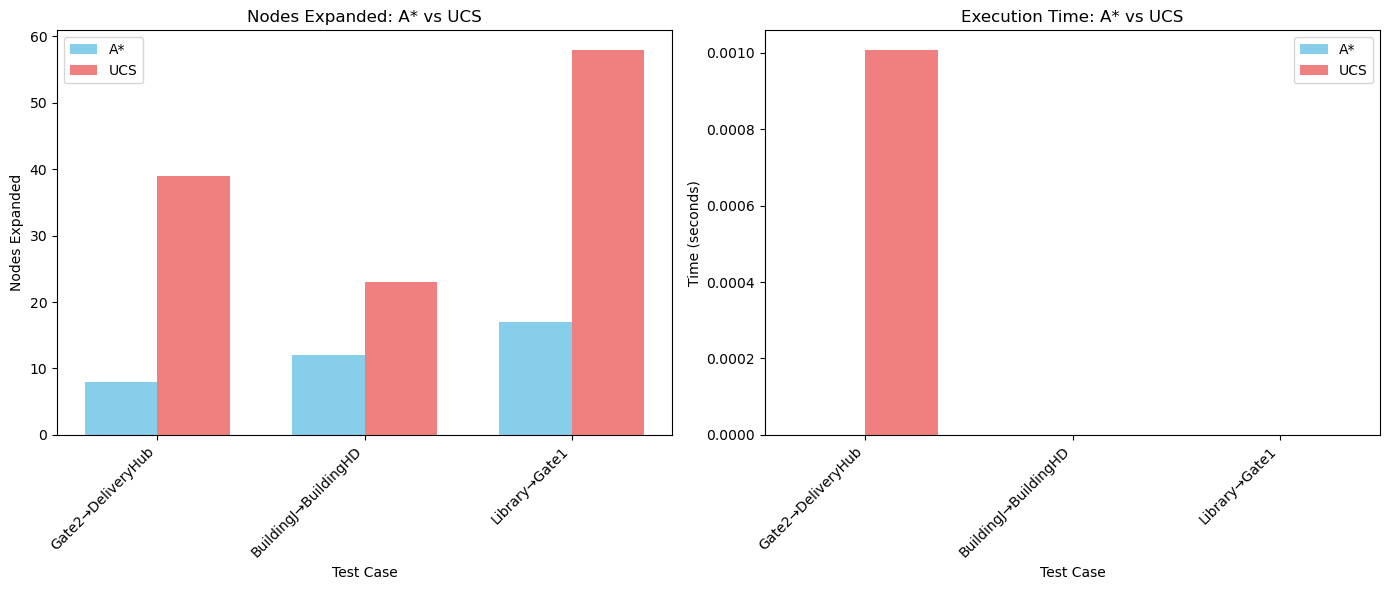


[4] Algorithm Comparison Summary:
              test_case  astar_nodes  ucs_nodes  astar_time  ucs_time
0     Gate2→DeliveryHub            8         39         0.0  0.001008
1  BuildingJ→BuildingHD           12         23         0.0  0.000000
2         Library→Gate1           17         58         0.0  0.000000

[5] Evaluating Heuristic Performance (Task 4)...

Comparing Heuristics: Gate2 -> DeliveryHub

--- Baseline Heuristic (Manhattan Distance) ---

--- Enhanced Heuristic ---

Improvement: -50.0% fewer nodes expanded

Comparing Heuristics: BuildingJ -> BuildingHD

--- Baseline Heuristic (Manhattan Distance) ---

--- Enhanced Heuristic ---

Improvement: 8.3% fewer nodes expanded

Comparing Heuristics: Library -> Gate1

--- Baseline Heuristic (Manhattan Distance) ---

--- Enhanced Heuristic ---

Improvement: 0.0% fewer nodes expanded


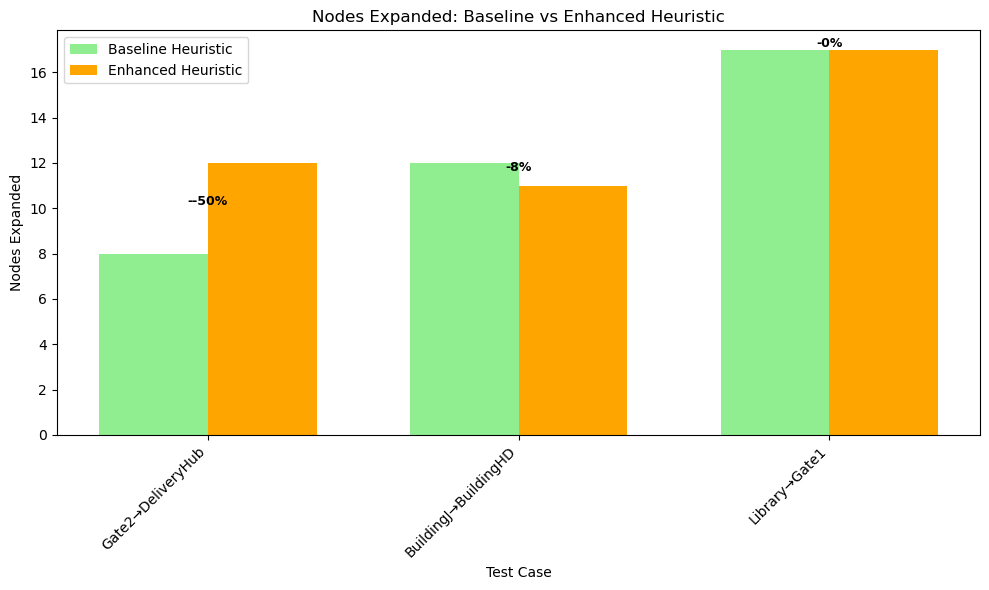


[6] Heuristic Comparison Summary:
              test_case  baseline_nodes  enhanced_nodes  improvement_pct
0     Gate2→DeliveryHub               8              12       -50.000000
1  BuildingJ→BuildingHD              12              11         8.333333
2         Library→Gate1              17              17         0.000000

[7] Results saved to CSV files:
   - algorithm_results.csv
   - heuristic_results.csv
   - campus_map.png
   - algorithm_comparison.png
   - heuristic_comparison.png

Assignment 1 Execution Complete!


In [48]:
#MAIN EXECUTION
def main():
    """Main execution function."""
    print("="*70)
    print("SIT215 Assignment 1: Truck Delivery Navigation System")
    print("="*70)
    
    # Initialize environment
    print("\n[1] Initializing Truck Delivery Environment...")
    env = TruckDeliveryEnvironment()
    print(f"   - {len(env.landmarks)} landmarks")
    print(f"   - {len(env.paths)} path segments")
    print(f"   - Static constraints: narrow roads, height restrictions")
    print(f"   - Dynamic constraints: delivery hours, peak hours")
    
    # Visualize the graph
    print("\n[2] Visualizing campus map...")
    visualize_graph(env)
    
    # Define test cases (Task 3 requirement: at least 3 start-goal pairs)
    test_cases = [
        ('Gate2', 'DeliveryHub'),      # Entry to delivery point
        ('BuildingJ', 'BuildingHD'),   # Cross-campus delivery
        ('Library', 'Gate1'),          # Library to exit
        ('Parking', 'BuildingIC'),     # Parking to north campus
        ('BuildingEF', 'BuildingKW')   # East to west route
    ]
    
    # Task 3: Evaluate algorithms
    print("\n[3] Evaluating Search Algorithms (Task 3)...")
    algorithm_results = evaluate_algorithms(env, test_cases[:3])  # First 3 test cases
    
    # Create comparison visualization
    plot_comparison_results(algorithm_results)
    
    # Display summary table
    print("\n[4] Algorithm Comparison Summary:")
    summary_df = pd.DataFrame(algorithm_results)
    print(summary_df[['test_case', 'astar_nodes', 'ucs_nodes', 'astar_time', 'ucs_time']].to_string())
    
    # Task 4: Evaluate heuristics
    print("\n[5] Evaluating Heuristic Performance (Task 4)...")
    heuristic_results = evaluate_heuristics(env, test_cases[:3])
    
    # Create heuristic comparison visualization
    plot_heuristic_comparison(heuristic_results)
    
    # Display heuristic comparison summary
    print("\n[6] Heuristic Comparison Summary:")
    heur_df = pd.DataFrame(heuristic_results)
    print(heur_df[['test_case', 'baseline_nodes', 'enhanced_nodes', 'improvement_pct']].to_string())
    
    # Save all results
    algorithm_results_df = pd.DataFrame(algorithm_results)
    heuristic_results_df = pd.DataFrame(heuristic_results)
    
    algorithm_results_df.to_csv('algorithm_results.csv', index=False)
    heuristic_results_df.to_csv('heuristic_results.csv', index=False)
    
    print("\n[7] Results saved to CSV files:")
    print("   - algorithm_results.csv")
    print("   - heuristic_results.csv")
    print("   - campus_map.png")
    print("   - algorithm_comparison.png")
    print("   - heuristic_comparison.png")
    
    print("\n" + "="*70)
    print("Assignment 1 Execution Complete!")
    print("="*70)


if __name__ == "__main__":
    main()